# ZynForge ZynCrystalFlow：MP-20 条件晶体生成完整工作流

这个 Notebook 将前面加入 ZynForge 的 `ZynCrystalFlow` 模块作为外部 Python 包使用，
从公开数据开始完成一套可复现的条件材料生成流程：

1. 下载公开 MP-20 数据；
2. 解析、过滤、缓存晶体结构；
3. 构造组成、元素集合、原子数、空间群、晶系和性质条件；
4. 训练联合周期流匹配生成器；
5. 保存 `best.pt`、`last.pt` 和 `history.jsonl`；
6. 从最佳 EMA checkpoint 恢复模型；
7. 进行无条件、精确组成、空间群和多性质条件生成；
8. 可选使用 ZynField 势能进行可微低能引导；
9. 进行结构弛豫、性质预测、约束筛选和去重；
10. 计算有效性、唯一性、新颖性、条件命中率和透明的 SUN 边界；
11. 建立生成式主动学习选择队列，导出待 DFT 结构。

## 公开数据

默认使用 CDVAE 发布的 MP-20 固定划分。MP-20 是晶体生成领域的标准公开基准，
包含约 4.5 万个无机晶体，晶胞原子数不超过 20。

- 数据仓库：`https://github.com/txie-93/cdvae/tree/main/data/mp_20`
- MatterGen 复现实验也提供 MP-20 数据入口：
  `https://github.com/microsoft/mattergen/tree/main/data-release/mp-20`

## 科学边界

- 本 Notebook 可以严格计算结构有效性、唯一性、组成/空间群/性质条件命中率和
  相对于公开参考结构的结构新颖性。
- `energy_above_hull`、稳定率和 SUN 只有在提供独立且能量标尺一致的稳定性 oracle
  时才有效。
- 普通组成回归器和几何有效性不会被当作 DFT 稳定性。
- 最终候选仍应使用统一参数的 DFT 工作流确认。

## 0. 运行档位

推荐先运行 `smoke` 验证环境，再切换到 `rtx5080`。

| 档位 | 数据量 | 模型 | Epoch | 用途 |
|---|---:|---:|---:|---|
| `smoke` | 合成小数据 | 64 × 2 层 | 2 | 验证完整工作流 |
| `quick` | MP-20 子集 | 192 × 6 层 | 50 | 快速实验 |
| `rtx5080` | 完整 MP-20 | 256 × 8 层 | 200 | 单张 RTX 5080 正式训练 |
| `foundation` | 完整 MP-20/Alex-MP-20 | 384 × 12 层 | 400 | 多卡基础模型 |

正式版默认设为 `rtx5080`。通过环境变量可以覆盖所有关键参数。

## 进度显示

本 Notebook 的统一进度条覆盖：

- MP-20 解析与缓存；
- 每个 epoch 内的 train/valid batch；
- 条件流采样的每个 ODE 步；
- 晶体解码、弛豫、筛选与去重；
- 主动学习候选评分和多样性选择。

可通过环境变量控制：

```bash
export ZYNCRYSTALFLOW_PROGRESS_BAR=1
export ZYNCRYSTALFLOW_PROGRESS_INTERVAL=10
export ZYNCRYSTALFLOW_PROGRESS_LEAVE=1
export ZYNCRYSTALFLOW_SHOW_MEMORY=1
export ZYNCRYSTALFLOW_RELAXATION_PROGRESS_BAR=1
```

In [1]:
# 在首次导入 ZynNova 之前设置。
import os
from pathlib import Path

PROJECT_ROOT = Path(
    os.environ.get("ZYNNOVA_PROJECT_ROOT", "/home/zephyrain/lw/ZynNova")
).expanduser().resolve()

PROFILE = os.environ.get("ZYNCRYSTALFLOW_PROFILE", "rtx5080").lower()
RUN_MODE = os.environ.get("ZYNCRYSTALFLOW_RUN_MODE", "train").lower()
SEED = int(os.environ.get("ZYNCRYSTALFLOW_SEED", "42"))

PROGRESS_BAR = os.environ.get("ZYNCRYSTALFLOW_PROGRESS_BAR", "1") == "1"
PROGRESS_INTERVAL = int(
    os.environ.get("ZYNCRYSTALFLOW_PROGRESS_INTERVAL", "10")
)
PROGRESS_LEAVE = os.environ.get(
    "ZYNCRYSTALFLOW_PROGRESS_LEAVE", "1"
) == "1"
PROGRESS_SHOW_MEMORY = os.environ.get(
    "ZYNCRYSTALFLOW_SHOW_MEMORY", "1"
) == "1"
RELAXATION_PROGRESS_BAR = os.environ.get(
    "ZYNCRYSTALFLOW_RELAXATION_PROGRESS_BAR", "1"
) == "1"

WORK_ROOT = Path(
    os.environ.get(
        "ZYNCRYSTALFLOW_WORK_ROOT",
        str(PROJECT_ROOT.parent / "zyncrystalflow_mp20_workspace"),
    )
).expanduser().resolve()

DATA_ROOT = WORK_ROOT / "data"
CACHE_ROOT = WORK_ROOT / "cache"
RUNS_ROOT = WORK_ROOT / "runs"
RESULTS_ROOT = WORK_ROOT / "results" / f"mp20-{PROFILE}"

for directory in (DATA_ROOT, CACHE_ROOT, RUNS_ROOT, RESULTS_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

# 可选：已有 ZynField checkpoint。
ZYNFIELD_CHECKPOINT = os.environ.get("ZYNCRYSTALFLOW_ZYNFIELD_CHECKPOINT", "").strip()

# 只有经过独立校准的 energy-above-hull oracle 才应设为 1。
ALLOW_PROXY_STABILITY = (
    os.environ.get("ZYNCRYSTALFLOW_ALLOW_PROXY_STABILITY", "0") == "1"
)

print("Project root :", PROJECT_ROOT)
print("Profile      :", PROFILE)
print("Run mode     :", RUN_MODE)
print("Work root    :", WORK_ROOT)
print("Results root :", RESULTS_ROOT)
print("Progress     :", PROGRESS_BAR, "interval=", PROGRESS_INTERVAL)
print("ZynField     :", ZYNFIELD_CHECKPOINT or "<disabled>")

Project root : /home/zephyrain/lw/ZynNova
Profile      : rtx5080
Run mode     : train
Work root    : /home/zephyrain/lw/zyncrystalflow_mp20_workspace
Results root : /home/zephyrain/lw/zyncrystalflow_mp20_workspace/results/mp20-rtx5080
Progress     : True interval= 10
ZynField     : <disabled>


## 1. 安装与导入检查

项目需要已经覆盖 ZynCrystalFlow 新增文件。推荐安装：

```bash
cd /home/zephyrain/lw/ZynNova
pip install -e ".[zynforge-generation,zynforge-field]"
pip install scikit-learn tqdm
```

Notebook 会检查导入路径，避免误用另一个环境中的旧版 `zynnova`。

In [2]:
import sys
import importlib
import platform

if PROJECT_ROOT.exists():
    source_root = PROJECT_ROOT / "src"
    if str(source_root) not in sys.path:
        sys.path.insert(0, str(source_root))

import zynnova
from zynnova.ml.zynforge import generation as generation_module

print("Python       :", sys.version.split()[0])
print("Platform     :", platform.platform())
print("ZynNova     :", Path(zynnova.__file__).resolve())
print("Generation   :", Path(generation_module.__file__).resolve())

assert hasattr(generation_module, "ZynCrystalFlow")
assert hasattr(generation_module, "train_zyncrystalflow")
assert hasattr(generation_module, "benchmark_generator")

Python       : 3.12.13
Platform     : Linux-5.15.167.4-microsoft-standard-WSL2-x86_64-with-glibc2.35
ZynNova     : /home/zephyrain/lw/ZynNova/src/zynnova/__init__.py
Generation   : /home/zephyrain/lw/ZynNova/src/zynnova/ml/zynforge/generation/__init__.py


In [3]:
import dataclasses
import json
import math
import pickle
import random
import shutil
import time
import warnings
from collections import Counter, defaultdict
from dataclasses import asdict, replace
from pathlib import Path
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(values, **kwargs):
        return values

from zynnova.ml.zynforge.generation import (
    CrystalRecord,
    GenerationBenchmarkConfig,
    GenerationCondition,
    GenerativeAcquisitionConfig,
    GenerativeActiveLearningLoop,
    PropertyTarget,
    PymatgenSymmetryProjector,
    ZynCrystalFlow,
    ZynCrystalFlowModelConfig,
    ZynCrystalFlowTrainConfig,
    ZynCrystalRefinementConfig,
    ZynCrystalRefiner,
    ZynCrystalSampler,
    ZynCrystalSamplerConfig,
    ZynFieldEnergyGuide,
    ZynForgeDesigner,
    benchmark_generator,
    collate_crystal_records,
    evaluate_generated_crystals,
    flow_matching_loss,
    interpolate_crystal,
    load_zyncrystalflow,
    sample_prior_like,
    save_generated_crystals,
    train_zyncrystalflow,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))

Device: cuda
GPU   : NVIDIA GeForce RTX 5080


## 2. 公开 MP-20 数据下载

默认直接下载 CDVAE 仓库中的固定 CSV 划分：

```text
train.csv
val.csv
test.csv
```

可以通过 `ZYNCRYSTALFLOW_MP20_BASE_URL` 替换为镜像地址。
下载函数支持已有文件复用和临时文件原子替换。

In [4]:
from urllib.request import Request, urlopen
from urllib.error import URLError, HTTPError

MP20_BASE_URL = os.environ.get(
    "ZYNCRYSTALFLOW_MP20_BASE_URL",
    "https://raw.githubusercontent.com/txie-93/cdvae/main/data/mp_20",
).rstrip("/")

MP20_URLS = {
    "train": f"{MP20_BASE_URL}/train.csv",
    "valid": f"{MP20_BASE_URL}/val.csv",
    "test": f"{MP20_BASE_URL}/test.csv",
}

def download_with_retries(
    url: str,
    destination: Path,
    *,
    attempts: int = 4,
    timeout: int = 120,
) -> Path:
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.is_file() and destination.stat().st_size > 1024:
        return destination

    temporary = destination.with_suffix(destination.suffix + ".part")
    last_error = None
    for attempt in range(1, attempts + 1):
        try:
            request = Request(
                url,
                headers={"User-Agent": "ZynForge-ZynCrystalFlow"},
            )
            with urlopen(request, timeout=timeout) as response, temporary.open("wb") as handle:
                shutil.copyfileobj(response, handle)
            if temporary.stat().st_size <= 1024:
                raise RuntimeError(f"downloaded file is unexpectedly small: {temporary}")
            temporary.replace(destination)
            return destination
        except (OSError, URLError, HTTPError, RuntimeError) as exc:
            last_error = exc
            if temporary.exists():
                temporary.unlink()
            if attempt == attempts:
                break
            time.sleep(2 ** (attempt - 1))
    raise RuntimeError(f"failed to download {url}") from last_error

if PROFILE == "smoke":
    print("Smoke profile uses generated crystal records; public download is skipped.")
    split_paths = {}
else:
    split_paths = {
        split: download_with_retries(url, DATA_ROOT / "mp_20" / f"{split}.csv")
        for split, url in MP20_URLS.items()
    }
    for split, path in split_paths.items():
        print(f"{split:>5}:", path, f"({path.stat().st_size / 2**20:.1f} MiB)")

train: /home/zephyrain/lw/zyncrystalflow_mp20_workspace/data/mp_20/train.csv (33.4 MiB)
valid: /home/zephyrain/lw/zyncrystalflow_mp20_workspace/data/mp_20/valid.csv (11.1 MiB)
 test: /home/zephyrain/lw/zyncrystalflow_mp20_workspace/data/mp_20/test.csv (11.1 MiB)


## 3. MP-20 结构解析、条件构造与缓存

解析器兼容常见字段：

- `cif`
- `structure`
- `structure_json`

自动构造的条件包括：

- 精确组成；
- 允许元素集合；
- 原子数；
- 空间群；
- 晶系；
- 三维周期性；
- 密度；
- CSV 中存在的形成能、凸包能量、带隙、体模量和磁密度。

为了与 MatterGen 的常用过滤范围接近，默认排除 `Tc`、`Pm`、稀有气体以及
原子序数大于 84 的元素。所有过滤均可以通过环境变量修改。

In [5]:
from pymatgen.core import Element, Lattice, Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

CRYSTAL_SYSTEM_TO_ID = {
    "triclinic": 0,
    "monoclinic": 1,
    "orthorhombic": 2,
    "tetragonal": 3,
    "trigonal": 4,
    "hexagonal": 5,
    "cubic": 6,
}

PROPERTY_ALIASES = {
    "formation_energy_per_atom": (
        "formation_energy_per_atom",
        "formation_energy",
        "formation_energy_per_atom_ev",
    ),
    "energy_above_hull": (
        "energy_above_hull",
        "e_above_hull",
        "dft_energy_above_hull",
    ),
    "band_gap": ("band_gap", "dft_band_gap", "gap"),
    "bulk_modulus": ("bulk_modulus", "dft_bulk_modulus", "ml_bulk_modulus"),
    "magnetic_density": ("magnetic_density", "dft_mag_density", "mag_density"),
}

PROPERTY_NAMES = (
    "formation_energy_per_atom",
    "energy_above_hull",
    "band_gap",
    "bulk_modulus",
    "magnetic_density",
    "density",
)

STRUCTURE_COLUMNS = ("cif", "structure", "structure_json", "structure_dict")
ID_COLUMNS = ("material_id", "mp_id", "id", "task_id")

EXCLUDED_ATOMIC_NUMBERS = {
    2, 10, 18, 36, 54, 86,  # noble gases
    43, 61,                 # Tc and Pm
}
MAX_ATOMIC_NUMBER = int(os.environ.get("ZYNCRYSTALFLOW_MAX_ATOMIC_NUMBER", "84"))
MAX_ATOMS = int(os.environ.get("ZYNCRYSTALFLOW_MAX_ATOMS", "20"))
SYMPREC = float(os.environ.get("ZYNCRYSTALFLOW_SYMPREC", "0.1"))

def first_existing(columns, candidates):
    for name in candidates:
        if name in columns:
            return name
    return None

def parse_structure(value: Any) -> Structure:
    if isinstance(value, Structure):
        return value
    if isinstance(value, dict):
        return Structure.from_dict(value)
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        raise ValueError("empty structure value")
    text = str(value).strip()
    if not text:
        raise ValueError("empty structure text")
    if text.startswith("{"):
        return Structure.from_dict(json.loads(text))
    try:
        return Structure.from_str(text, fmt="cif")
    except Exception:
        payload = json.loads(text)
        return Structure.from_dict(payload)

def finite_float(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return None
    return value if np.isfinite(value) else None

def structure_properties(structure: Structure, row: pd.Series) -> dict[str, float]:
    result: dict[str, float] = {"density": float(structure.density)}
    for canonical, aliases in PROPERTY_ALIASES.items():
        column = first_existing(row.index, aliases)
        if column is None:
            continue
        value = finite_float(row[column])
        if value is not None:
            result[canonical] = value
    return result

def condition_from_structure(
    structure: Structure,
    properties: dict[str, float],
    *,
    material_id: str,
) -> GenerationCondition:
    atomic_numbers = [int(site.specie.Z) for site in structure]
    counts = Counter(atomic_numbers)

    analyzer = SpacegroupAnalyzer(
        structure,
        symprec=SYMPREC,
        angle_tolerance=5.0,
    )
    try:
        space_group = int(analyzer.get_space_group_number())
        crystal_system = CRYSTAL_SYSTEM_TO_ID[analyzer.get_crystal_system()]
    except Exception:
        space_group = None
        crystal_system = None

    property_targets = {
        name: PropertyTarget(
            target=float(value),
            tolerance=max(abs(float(value)) * 0.05, 1.0e-3),
        )
        for name, value in properties.items()
        if name in PROPERTY_NAMES
    }

    return GenerationCondition(
        allowed_elements=tuple(sorted(counts)),
        composition={int(z): float(amount) for z, amount in counts.items()},
        atom_count=len(atomic_numbers),
        space_group=space_group,
        crystal_system=crystal_system,
        dimensionality=3,
        properties=property_targets,
        metadata={"material_id": material_id},
    )

def row_to_record(row: pd.Series, *, split: str) -> CrystalRecord:
    structure_column = first_existing(row.index, STRUCTURE_COLUMNS)
    if structure_column is None:
        raise KeyError(f"no structure column found in {list(row.index)}")
    structure = parse_structure(row[structure_column])

    if len(structure) < 1 or len(structure) > MAX_ATOMS:
        raise ValueError("atom count outside configured range")
    atomic_numbers = np.asarray([int(site.specie.Z) for site in structure], dtype=np.int64)
    if atomic_numbers.max(initial=0) > MAX_ATOMIC_NUMBER:
        raise ValueError("atomic number exceeds configured maximum")
    if set(map(int, atomic_numbers)) & EXCLUDED_ATOMIC_NUMBERS:
        raise ValueError("structure contains an excluded element")
    lattice = np.asarray(structure.lattice.matrix, dtype=np.float64)
    frac = np.asarray(structure.frac_coords, dtype=np.float64)
    if not np.isfinite(lattice).all() or not np.isfinite(frac).all():
        raise ValueError("non-finite geometry")
    if abs(np.linalg.det(lattice)) <= 1.0e-6:
        raise ValueError("singular lattice")

    id_column = first_existing(row.index, ID_COLUMNS)
    material_id = str(row[id_column]) if id_column is not None else f"{split}-unknown"
    properties = structure_properties(structure, row)
    condition = condition_from_structure(
        structure,
        properties,
        material_id=material_id,
    )
    return CrystalRecord(
        atomic_numbers=atomic_numbers,
        frac_coords=frac,
        lattice=lattice,
        condition=condition,
        metadata={
            "material_id": material_id,
            "split": split,
            "properties": properties,
            "formula": structure.composition.reduced_formula,
            "space_group": condition.space_group,
            "crystal_system": condition.crystal_system,
        },
    )

In [6]:
def make_smoke_records(count: int, *, split: str, seed: int) -> list[CrystalRecord]:
    rng = np.random.default_rng(seed)
    prototypes = [
        ([11, 17], [[0, 0, 0], [0.5, 0.5, 0.5]], 5.64),          # NaCl-like
        ([3, 8, 3], [[0, 0, 0], [0.25, 0.25, 0.25], [0.5, 0.5, 0.5]], 4.62),
        ([14, 14], [[0, 0, 0], [0.25, 0.25, 0.25]], 5.43),       # Si-like
        ([13, 13, 13, 13], [[0, 0, 0], [0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]], 4.05),
    ]
    records = []
    for index in range(count):
        numbers, coords, base_length = prototypes[index % len(prototypes)]
        length = base_length * float(rng.uniform(0.96, 1.04))
        structure = Structure(
            Lattice.cubic(length),
            numbers,
            np.asarray(coords, dtype=float),
            coords_are_cartesian=False,
        )
        fake_formation = -float(0.5 + 0.02 * np.mean(numbers) + rng.normal(0, 0.02))
        properties = {
            "density": float(structure.density),
            "formation_energy_per_atom": fake_formation,
        }
        material_id = f"smoke-{split}-{index:04d}"
        records.append(
            CrystalRecord(
                atomic_numbers=np.asarray(numbers, dtype=np.int64),
                frac_coords=np.asarray(coords, dtype=np.float64),
                lattice=np.asarray(structure.lattice.matrix, dtype=np.float64),
                condition=condition_from_structure(
                    structure,
                    properties,
                    material_id=material_id,
                ),
                metadata={
                    "material_id": material_id,
                    "split": split,
                    "properties": properties,
                    "formula": structure.composition.reduced_formula,
                },
            )
        )
    return records

PROFILE_LIMITS = {
    "smoke": (32, 8, 8),
    "quick": (
        int(os.environ.get("ZYNCRYSTALFLOW_QUICK_TRAIN", "5000")),
        int(os.environ.get("ZYNCRYSTALFLOW_QUICK_VALID", "1000")),
        int(os.environ.get("ZYNCRYSTALFLOW_QUICK_TEST", "1000")),
    ),
    "rtx5080": (None, None, None),
    "foundation": (None, None, None),
}
if PROFILE not in PROFILE_LIMITS:
    raise ValueError(f"unknown profile: {PROFILE}")

def load_or_build_records(split: str, limit: int | None) -> list[CrystalRecord]:
    cache_name = (
        f"mp20-{split}-z{MAX_ATOMIC_NUMBER}-n{MAX_ATOMS}-"
        f"{'all' if limit is None else limit}.pkl"
    )
    cache_path = CACHE_ROOT / cache_name
    if cache_path.is_file():
        with cache_path.open("rb") as handle:
            return pickle.load(handle)

    frame = pd.read_csv(split_paths[split], low_memory=False)
    print(f"{split} columns:", list(frame.columns))
    if limit is not None:
        frame = frame.iloc[:limit].copy()

    records = []
    failures = Counter()
    for _, row in tqdm(
        frame.iterrows(),
        total=len(frame),
        desc=f"parse {split}",
    ):
        try:
            records.append(row_to_record(row, split=split))
        except Exception as exc:
            failures[type(exc).__name__] += 1

    with cache_path.open("wb") as handle:
        pickle.dump(records, handle, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"{split}: accepted={len(records)}, rejected={sum(failures.values())}")
    print("failure types:", dict(failures))
    return records

train_limit, valid_limit, test_limit = PROFILE_LIMITS[PROFILE]

if PROFILE == "smoke":
    train_records = make_smoke_records(train_limit, split="train", seed=SEED)
    valid_records = make_smoke_records(valid_limit, split="valid", seed=SEED + 1)
    test_records = make_smoke_records(test_limit, split="test", seed=SEED + 2)
else:
    train_records = load_or_build_records("train", train_limit)
    valid_records = load_or_build_records("valid", valid_limit)
    test_records = load_or_build_records("test", test_limit)

assert train_records and valid_records and test_records
print("Records:", len(train_records), len(valid_records), len(test_records))

train columns: ['Unnamed: 0', 'material_id', 'formation_energy_per_atom', 'band_gap', 'pretty_formula', 'e_above_hull', 'elements', 'cif', 'spacegroup.number']


parse train:   0%|          | 0/27136 [00:00<?, ?it/s]

/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while p

train: accepted=25325, rejected=1811
failure types: {'ValueError': 1811}
valid columns: ['Unnamed: 0', 'material_id', 'formation_energy_per_atom', 'band_gap', 'pretty_formula', 'e_above_hull', 'elements', 'cif', 'spacegroup.number']


parse valid:   0%|          | 0/9047 [00:00<?, ?it/s]

/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: 20 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while p

valid: accepted=8464, rejected=583
failure types: {'ValueError': 583}
test columns: ['Unnamed: 0', 'material_id', 'formation_energy_per_atom', 'band_gap', 'pretty_formula', 'e_above_hull', 'elements', 'cif', 'spacegroup.number']


parse test:   0%|          | 0/9046 [00:00<?, ?it/s]

/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
/home/zephyrain/anaconda3/envs/zynnova/lib/python3.12/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while p

test: accepted=8481, rejected=565
failure types: {'ValueError': 565}
Records: 25325 8464 8481


## 4. 数据集审计与可视化

检查原子数、元素覆盖、空间群、晶系和性质标签覆盖率。这里的统计结果同时决定
后续哪些性质条件和后处理回归器能够启用。

,material_id,formula,num_atoms,num_elements,space_group,crystal_system,volume_A3,density,formation_energy_per_atom,energy_above_hull,band_gap
0,mp-1221227,Na3MnCoNiO6,12,5,8,1,127.315333,4.402316,-1.637460,0.043001,0.2133
1,mp-974729,Nd(Al2Cu)4,13,3,139,3,205.971042,4.952313,-0.314759,0.000000,0.0000
2,mp-1185360,LiMnIr2,4,3,225,6,51.068091,14.512394,-0.193761,0.018075,0.0000
3,mp-1188861,LiCSN,16,4,62,2,254.597522,1.696386,-0.584694,0.048847,3.8556
4,mp-677272,La2EuS4,14,3,122,3,335.806370,5.518888,-2.474759,0.000000,0.4707


,train_non_null,valid_non_null,test_non_null
formation_energy_per_atom,25325,8464,8481
energy_above_hull,25325,8464,8481
band_gap,25325,8464,8481
bulk_modulus,0,0,0
magnetic_density,0,0,0
density,25325,8464,8481


Distinct elements: 76
Most common atomic numbers: [(8, 51656), (9, 12714), (16, 10204), (3, 6399), (34, 5946), (28, 5770), (17, 5388), (26, 5161), (29, 4991), (27, 4979), (32, 4659), (25, 4609), (14, 4478), (13, 4103), (31, 3934), (52, 3849), (50, 3571), (12, 3563), (23, 3300), (38, 3199)]


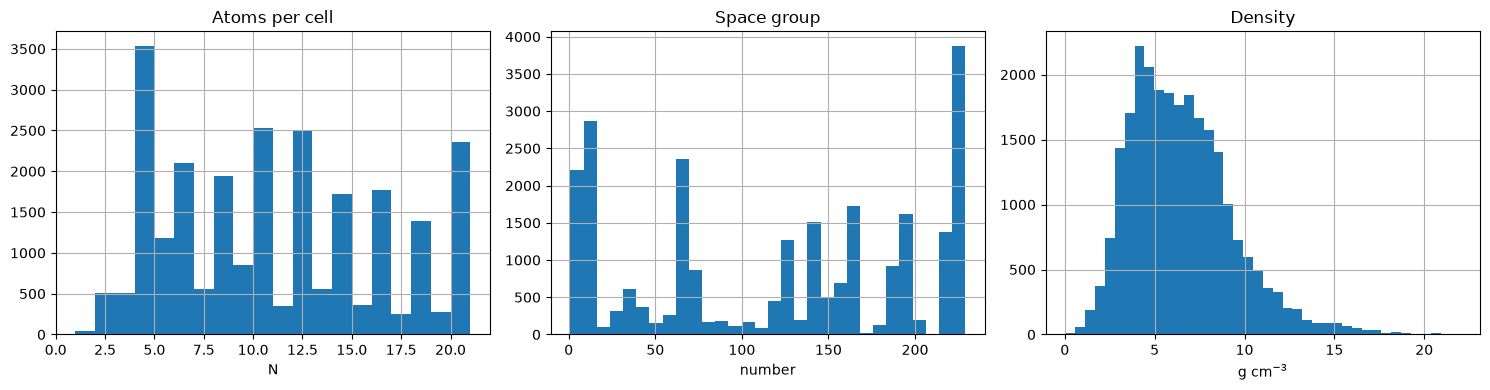

In [7]:
def records_dataframe(records):
    rows = []
    for record in records:
        props = dict(record.metadata.get("properties", {}))
        row = {
            "material_id": record.metadata.get("material_id"),
            "formula": record.metadata.get("formula"),
            "num_atoms": len(record.atomic_numbers),
            "num_elements": len(set(map(int, record.atomic_numbers))),
            "space_group": record.condition.space_group,
            "crystal_system": record.condition.crystal_system,
            "volume_A3": abs(float(np.linalg.det(np.asarray(record.lattice)))),
        }
        row.update(props)
        rows.append(row)
    return pd.DataFrame(rows)

train_df = records_dataframe(train_records)
valid_df = records_dataframe(valid_records)
test_df = records_dataframe(test_records)

display(train_df.head())
coverage = pd.DataFrame({
    "train_non_null": train_df.reindex(columns=PROPERTY_NAMES).notna().sum(),
    "valid_non_null": valid_df.reindex(columns=PROPERTY_NAMES).notna().sum(),
    "test_non_null": test_df.reindex(columns=PROPERTY_NAMES).notna().sum(),
})
display(coverage)

element_counts = Counter(
    int(z)
    for record in train_records
    for z in record.atomic_numbers
)
print("Distinct elements:", len(element_counts))
print("Most common atomic numbers:", element_counts.most_common(20))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train_df["num_atoms"].hist(ax=axes[0], bins=range(1, MAX_ATOMS + 2))
axes[0].set_title("Atoms per cell")
axes[0].set_xlabel("N")

train_df["space_group"].dropna().astype(int).hist(ax=axes[1], bins=30)
axes[1].set_title("Space group")
axes[1].set_xlabel("number")

train_df["density"].dropna().hist(ax=axes[2], bins=40)
axes[2].set_title("Density")
axes[2].set_xlabel("g cm$^{-3}$")

plt.tight_layout()
plt.savefig(RESULTS_ROOT / "dataset_statistics.png", dpi=180)
plt.show()

## 5. 模型与训练配置

ZynCrystalFlow 联合学习：

- 元素单纯形流；
- 周期分数坐标环面流；
- 正定晶格 log-Cholesky 流；
- 可选无序占位流；
- 原子数分布；
- 组成和允许元素一致性。

MP-20 是有序晶体数据，因此默认 `generate_disorder=False`。

In [8]:
if PROFILE == "smoke":
    model_config = ZynCrystalFlowModelConfig(
        max_atomic_number=MAX_ATOMIC_NUMBER,
        max_atoms=8,
        hidden_dim=64,
        num_layers=2,
        num_attention_heads=4,
        edge_dim=32,
        num_fourier_features=8,
        time_dim=64,
        condition_dim=64,
        property_names=PROPERTY_NAMES,
        dropout=0.0,
        condition_dropout=0.10,
        generate_disorder=False,
    )
    train_config = ZynCrystalFlowTrainConfig(
        epochs=2,
        batch_size=4,
        gradient_accumulation=1,
        learning_rate=5.0e-4,
        min_learning_rate=1.0e-5,
        warmup_epochs=0,
        mixed_precision="none",
        device="auto",
        output_dir=RUNS_ROOT / "smoke",
        patience=5,
        num_workers=0,
        seed=SEED,
        progress_bar=PROGRESS_BAR,
        progress_update_interval=PROGRESS_INTERVAL,
        progress_leave=PROGRESS_LEAVE,
        progress_show_memory=PROGRESS_SHOW_MEMORY,
    )
elif PROFILE == "quick":
    model_config = ZynCrystalFlowModelConfig(
        max_atomic_number=MAX_ATOMIC_NUMBER,
        max_atoms=MAX_ATOMS,
        hidden_dim=192,
        num_layers=6,
        num_attention_heads=8,
        edge_dim=80,
        time_dim=96,
        condition_dim=192,
        property_names=PROPERTY_NAMES,
        condition_dropout=0.15,
        generate_disorder=False,
    )
    train_config = ZynCrystalFlowTrainConfig(
        epochs=50,
        batch_size=8,
        gradient_accumulation=2,
        learning_rate=2.0e-4,
        min_learning_rate=1.0e-6,
        warmup_epochs=5,
        mixed_precision="bf16",
        device="auto",
        output_dir=RUNS_ROOT / "quick",
        patience=15,
        num_workers=0,
        seed=SEED,
        progress_bar=PROGRESS_BAR,
        progress_update_interval=PROGRESS_INTERVAL,
        progress_leave=PROGRESS_LEAVE,
        progress_show_memory=PROGRESS_SHOW_MEMORY,
    )
elif PROFILE == "rtx5080":
    model_config = ZynCrystalFlowModelConfig.rtx5080(
        max_atomic_number=MAX_ATOMIC_NUMBER,
        max_atoms=MAX_ATOMS,
        property_names=PROPERTY_NAMES,
        generate_disorder=False,
    )
    train_config = ZynCrystalFlowTrainConfig(
        epochs=int(os.environ.get("ZYNCRYSTALFLOW_EPOCHS", "200")),
        batch_size=int(os.environ.get("ZYNCRYSTALFLOW_BATCH_SIZE", "8")),
        gradient_accumulation=int(
            os.environ.get("ZYNCRYSTALFLOW_GRADIENT_ACCUMULATION", "2")
        ),
        learning_rate=2.0e-4,
        min_learning_rate=1.0e-6,
        warmup_epochs=10,
        mixed_precision="bf16",
        device="auto",
        output_dir=RUNS_ROOT / "rtx5080",
        patience=40,
        num_workers=int(os.environ.get("ZYNCRYSTALFLOW_NUM_WORKERS", "0")),
        seed=SEED,
        progress_bar=PROGRESS_BAR,
        progress_update_interval=PROGRESS_INTERVAL,
        progress_leave=PROGRESS_LEAVE,
        progress_show_memory=PROGRESS_SHOW_MEMORY,
    )
else:
    model_config = ZynCrystalFlowModelConfig.foundation(
        max_atomic_number=MAX_ATOMIC_NUMBER,
        max_atoms=MAX_ATOMS,
        property_names=PROPERTY_NAMES,
        generate_disorder=False,
    )
    train_config = ZynCrystalFlowTrainConfig(
        epochs=int(os.environ.get("ZYNCRYSTALFLOW_EPOCHS", "400")),
        batch_size=int(os.environ.get("ZYNCRYSTALFLOW_BATCH_SIZE", "4")),
        gradient_accumulation=int(
            os.environ.get("ZYNCRYSTALFLOW_GRADIENT_ACCUMULATION", "8")
        ),
        learning_rate=2.0e-4,
        min_learning_rate=1.0e-6,
        warmup_epochs=15,
        mixed_precision="bf16",
        device="auto",
        output_dir=RUNS_ROOT / "foundation",
        patience=60,
        num_workers=int(os.environ.get("ZYNCRYSTALFLOW_NUM_WORKERS", "0")),
        seed=SEED,
        progress_bar=PROGRESS_BAR,
        progress_update_interval=PROGRESS_INTERVAL,
        progress_leave=PROGRESS_LEAVE,
        progress_show_memory=PROGRESS_SHOW_MEMORY,
    )

resume_path = os.environ.get("ZYNCRYSTALFLOW_RESUME_CHECKPOINT", "").strip()
if resume_path:
    train_config.resume_checkpoint = Path(resume_path).expanduser().resolve()

configuration = {
    "profile": PROFILE,
    "model_config": asdict(model_config),
    "train_config": {
        **asdict(train_config),
        "output_dir": str(train_config.output_dir),
        "resume_checkpoint": (
            None
            if train_config.resume_checkpoint is None
            else str(train_config.resume_checkpoint)
        ),
    },
    "train_records": len(train_records),
    "valid_records": len(valid_records),
    "test_records": len(test_records),
    "effective_batch": (
        train_config.batch_size * train_config.gradient_accumulation
    ),
}
(RESULTS_ROOT / "configuration.json").write_text(
    json.dumps(configuration, indent=2, default=str),
    encoding="utf-8",
)
display(pd.Series({
    "architecture": model_config.architecture_version,
    "hidden_dim": model_config.hidden_dim,
    "layers": model_config.num_layers,
    "heads": model_config.num_attention_heads,
    "max_atoms": model_config.max_atoms,
    "properties": ", ".join(model_config.property_names),
    "epochs": train_config.epochs,
    "micro_batch": train_config.batch_size,
    "gradient_accumulation": train_config.gradient_accumulation,
    "effective_batch": train_config.batch_size * train_config.gradient_accumulation,
}))

architecture                                    zynforge-zyncrystalflow-v1
hidden_dim                                                             256
layers                                                                   8
heads                                                                    8
max_atoms                                                               20
properties               formation_energy_per_atom, energy_above_hull, ...
epochs                                                                 200
micro_batch                                                              8
gradient_accumulation                                                    2
effective_batch                                                         16
dtype: object

## 6. 单批次预检

在正式训练前验证：

- 数据张量形状；
- 周期流插值；
- 所有损失分量有限；
- 反向传播正常；
- GPU 峰值显存；
- 模型参数量。

In [9]:
from zynnova.ml.zynforge.generation.geometry import log_cholesky_to_lattice

preflight_model = ZynCrystalFlow(model_config).to(DEVICE)
preflight_batch = collate_crystal_records(
    train_records[: min(train_config.batch_size, len(train_records))],
    model_config=model_config,
    dtype=torch.float32,
)
target = preflight_batch["target"].to(DEVICE, torch.float32)
conditions_batch = preflight_batch["conditions"].to(DEVICE, torch.float32)
lattice_batch = preflight_batch["lattice"].to(DEVICE, torch.float32)

generator = torch.Generator(device=DEVICE).manual_seed(SEED)
prior = sample_prior_like(target, generator=generator)
time_value = torch.rand(target.batch_size, device=DEVICE, generator=generator)
state, targets = interpolate_crystal(prior, target, time_value)

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

started = time.perf_counter()
output = preflight_model(state, time_value, conditions_batch)
loss_result = flow_matching_loss(
    output,
    targets,
    state,
    train_config,
    lattice=lattice_batch,
    conditions=conditions_batch,
    time=time_value,
)
loss_result.loss.backward()
elapsed = time.perf_counter() - started

assert torch.isfinite(loss_result.loss)
assert all(np.isfinite(value) for value in loss_result.metrics.values())

preflight = {
    "parameters": sum(parameter.numel() for parameter in preflight_model.parameters()),
    "seconds_per_micro_batch": elapsed,
    "peak_allocated_GB": (
        torch.cuda.max_memory_allocated() / 2**30 if torch.cuda.is_available() else 0.0
    ),
    "peak_reserved_GB": (
        torch.cuda.max_memory_reserved() / 2**30 if torch.cuda.is_available() else 0.0
    ),
    **loss_result.metrics,
}
display(pd.Series(preflight))

del preflight_model, preflight_batch, target, conditions_batch
del lattice_batch, prior, state, targets, output, loss_result
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/home/zephyrain/lw/ZynNova/src/zynnova/ml/zynforge/generation/dataset.py:61: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  lattice[row] = torch.as_tensor(record.lattice, dtype=dtype)


parameters                 8.339727e+06
seconds_per_micro_batch    1.244143e+00
peak_allocated_GB          2.367377e-01
peak_reserved_GB           2.695312e-01
loss                       6.178957e+03
atom_loss                  3.084913e+03
coordinate_loss            2.673895e-01
lattice_loss               4.786854e+00
occupancy_loss             0.000000e+00
count_loss                 3.217646e+00
repulsion_loss             2.703271e-02
condition_loss             5.949172e-01
composition_loss           1.674730e-01
allowed_element_loss       4.274442e-01
dtype: float64

## 7. 从头训练或断点续训

训练器每个 epoch 都会写入：

```text
<run>/checkpoints/best.pt
<run>/checkpoints/last.pt
<run>/logs/history.jsonl
```

`ZYNCRYSTALFLOW_RESUME_CHECKPOINT` 可指向 `last.pt` 实现完整恢复。

In [ ]:
training_result = None

if RUN_MODE == "train":
    started = time.perf_counter()
    training_result = train_zyncrystalflow(
        train_records,
        valid_records,
        model_config=model_config,
        train_config=train_config,
    )
    training_seconds = time.perf_counter() - started
    BEST_CHECKPOINT = Path(training_result.best_checkpoint).resolve()
    LAST_CHECKPOINT = Path(training_result.last_checkpoint).resolve()
    RUN_DIR = Path(training_result.run_dir).resolve()
elif RUN_MODE == "evaluate":
    checkpoint_value = os.environ.get("ZYNCRYSTALFLOW_CHECKPOINT", "").strip()
    if not checkpoint_value:
        raise RuntimeError(
            "evaluate mode requires ZYNCRYSTALFLOW_CHECKPOINT"
        )
    BEST_CHECKPOINT = Path(checkpoint_value).expanduser().resolve()
    LAST_CHECKPOINT = BEST_CHECKPOINT
    RUN_DIR = BEST_CHECKPOINT.parent.parent
    training_seconds = None
else:
    raise ValueError("RUN_MODE must be train or evaluate")

HISTORY_FILE = RUN_DIR / "logs" / "history.jsonl"
assert BEST_CHECKPOINT.is_file(), BEST_CHECKPOINT
assert HISTORY_FILE.is_file(), (
    "checkpoint exists but history.jsonl is missing",
    RUN_DIR,
)

print("Run directory   :", RUN_DIR)
print("Best checkpoint :", BEST_CHECKPOINT)
print("Last checkpoint :", LAST_CHECKPOINT)
print("History         :", HISTORY_FILE)
print("Training seconds:", training_seconds)

## 8. 训练历史、最佳 checkpoint 与日志复制

In [ ]:
history_rows = [
    json.loads(line)
    for line in HISTORY_FILE.read_text(encoding="utf-8").splitlines()
    if line.strip()
]
history_df = pd.DataFrame(history_rows)
display(history_df.tail())

history_df.to_csv(RESULTS_ROOT / "training_history.csv", index=False)
shutil.copy2(HISTORY_FILE, RESULTS_ROOT / "history.jsonl")

metric_columns = [
    name for name in (
        "train_loss",
        "valid_loss",
        "valid_coordinate_loss",
        "valid_atom_loss",
        "valid_lattice_loss",
        "valid_condition_loss",
    )
    if name in history_df.columns
]

plt.figure(figsize=(10, 6))
for name in metric_columns:
    plt.plot(history_df["epoch"], history_df[name], label=name)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / "training_history.png", dpi=180)
plt.show()

model = load_zyncrystalflow(
    BEST_CHECKPOINT,
    device=str(DEVICE),
    use_ema=True,
)
model.eval()

print("Loaded architecture:", model.config.architecture_version)
print("Properties         :", model.config.property_names)
print("Parameter count    :", sum(p.numel() for p in model.parameters()))

## 9. 训练集性质代理模型

ZynCrystalFlow 的条件输入来自真实公开标签。为了在生成后给候选重新计算性质和
衡量条件命中率，Notebook 可训练轻量的结构/组成代理模型。

这些回归器只用于：

- 候选排序；
- 条件命中诊断；
- 主动学习不确定性。

它们**不等价于 DFT 稳定性 oracle**。

In [ ]:
def record_descriptor(record: CrystalRecord) -> np.ndarray:
    numbers = np.asarray(record.atomic_numbers, dtype=int)
    lattice = np.asarray(record.lattice, dtype=float)
    lengths = np.linalg.norm(lattice, axis=1)
    volume = abs(float(np.linalg.det(lattice)))
    fractions = np.zeros(MAX_ATOMIC_NUMBER + 1, dtype=float)
    for z in numbers:
        if 0 <= z <= MAX_ATOMIC_NUMBER:
            fractions[z] += 1.0
    fractions /= max(fractions.sum(), 1.0)
    structure = Structure(
        Lattice(lattice),
        numbers.tolist(),
        np.asarray(record.frac_coords),
        coords_are_cartesian=False,
    )
    scalar = np.asarray([
        len(numbers),
        len(set(map(int, numbers))),
        numbers.mean(),
        numbers.std(),
        numbers.min(),
        numbers.max(),
        volume / max(len(numbers), 1),
        float(structure.density),
        *lengths,
        *structure.lattice.angles,
    ], dtype=float)
    return np.concatenate((fractions[1:], scalar))

def atoms_descriptor(atoms) -> np.ndarray:
    numbers = np.asarray(atoms.get_atomic_numbers(), dtype=int)
    lattice = np.asarray(atoms.cell.array, dtype=float)
    record = CrystalRecord(
        atomic_numbers=numbers,
        frac_coords=atoms.get_scaled_positions(wrap=True),
        lattice=lattice,
    )
    return record_descriptor(record)

def exact_density(atoms) -> float:
    # 1 amu/A^3 = 1.66053906660 g/cm^3
    return float(atoms.get_masses().sum() * 1.66053906660 / atoms.get_volume())

property_predictors: dict[str, Callable] = {"density": exact_density}
trained_surrogates = {}

try:
    from sklearn.ensemble import ExtraTreesRegressor
    from sklearn.metrics import mean_absolute_error
except ImportError:
    ExtraTreesRegressor = None

if ExtraTreesRegressor is None:
    print("scikit-learn is not installed; only exact density will be evaluated.")
else:
    X_train = np.stack([record_descriptor(record) for record in train_records])
    X_valid = np.stack([record_descriptor(record) for record in valid_records])

    for property_name in PROPERTY_NAMES:
        if property_name == "density":
            continue
        y_train = np.asarray([
            record.metadata.get("properties", {}).get(property_name, np.nan)
            for record in train_records
        ], dtype=float)
        y_valid = np.asarray([
            record.metadata.get("properties", {}).get(property_name, np.nan)
            for record in valid_records
        ], dtype=float)
        train_mask = np.isfinite(y_train)
        valid_mask = np.isfinite(y_valid)

        minimum_labels = 20 if PROFILE == "smoke" else 200
        if train_mask.sum() < minimum_labels or valid_mask.sum() < 5:
            continue

        estimator = ExtraTreesRegressor(
            n_estimators=32 if PROFILE == "smoke" else 192,
            min_samples_leaf=1 if PROFILE == "smoke" else 2,
            max_features=0.8,
            n_jobs=-1,
            random_state=SEED,
        )
        estimator.fit(X_train[train_mask], y_train[train_mask])
        prediction = estimator.predict(X_valid[valid_mask])
        mae = mean_absolute_error(y_valid[valid_mask], prediction)
        trained_surrogates[property_name] = {
            "model": estimator,
            "valid_mae": float(mae),
            "labels": int(train_mask.sum()),
        }

        def make_predictor(model):
            def predictor(atoms):
                descriptor = atoms_descriptor(atoms)[None, :]
                tree_values = np.asarray([
                    tree.predict(descriptor)[0]
                    for tree in model.estimators_
                ])
                return float(tree_values.mean()), float(tree_values.std())
            return predictor

        property_predictors[property_name] = make_predictor(estimator)

surrogate_summary = {
    name: {
        "labels": values["labels"],
        "valid_mae": values["valid_mae"],
    }
    for name, values in trained_surrogates.items()
}
display(pd.DataFrame(surrogate_summary).T if surrogate_summary else pd.DataFrame())
(RESULTS_ROOT / "surrogate_metrics.json").write_text(
    json.dumps(surrogate_summary, indent=2),
    encoding="utf-8",
)

## 10. 可选 ZynField 势能引导

提供 `ZYNCRYSTALFLOW_ZYNFIELD_CHECKPOINT` 后，采样后半程可以使用统一
ZynField 能量梯度修正坐标和晶格，后处理也可以使用同一势函数完成结构弛豫。

In [ ]:
energy_guide = None
calculator_factory = None
zynfield_model = None

if ZYNFIELD_CHECKPOINT:
    from zynnova.ml.zynforge.field import (
        load_zynfield,
        zynfield_calculator,
    )

    zynfield_path = Path(ZYNFIELD_CHECKPOINT).expanduser().resolve()
    if not zynfield_path.is_file():
        raise FileNotFoundError(zynfield_path)

    zynfield_model = load_zynfield(
        zynfield_path,
        device=str(DEVICE),
        dtype="float32",
        use_ema=True,
    )
    zynfield_model.eval()
    energy_guide = ZynFieldEnergyGuide(zynfield_model)

    def calculator_factory():
        return zynfield_calculator(
            zynfield_model,
            device=str(DEVICE),
            dtype="float32",
        )

    print("ZynField energy guidance enabled.")
else:
    print("No ZynField checkpoint: energy guidance and physical relaxation are disabled.")

## 11. 条件生成任务

下面同时测试：

- 无条件生成；
- 精确组成；
- 允许元素集合；
- 空间群；
- 密度目标；
- 多性质范围条件。

`PropertyTarget` 只使用训练数据中存在或可精确重算的性质。

In [ ]:
def optional_property_targets(
    *,
    density_target: float | None = None,
    formation_maximum: float | None = None,
    band_gap_minimum: float | None = None,
):
    properties = {}
    if density_target is not None:
        properties["density"] = PropertyTarget(
            target=density_target,
            tolerance=0.75,
            weight=1.0,
        )
    if formation_maximum is not None and (
        "formation_energy_per_atom" in trained_surrogates
        or train_df["formation_energy_per_atom"].notna().any()
    ):
        properties["formation_energy_per_atom"] = PropertyTarget(
            maximum=formation_maximum,
            weight=1.5,
        )
    if band_gap_minimum is not None and "band_gap" in trained_surrogates:
        properties["band_gap"] = PropertyTarget(
            minimum=band_gap_minimum,
            weight=1.0,
        )
    return properties

generation_conditions = [
    GenerationCondition(
        atom_count_range=(2, min(12, model.config.max_atoms)),
        dimensionality=3,
        metadata={"name": "unconditional-size-controlled"},
    ),
    GenerationCondition(
        allowed_elements=(3, 8),
        composition={3: 2, 8: 1},
        atom_count=3,
        dimensionality=3,
        properties=optional_property_targets(density_target=2.0),
        metadata={"name": "exact-Li2O"},
    ),
    GenerationCondition(
        allowed_elements=(3, 8, 15, 26),
        atom_count_range=(7, min(20, model.config.max_atoms)),
        dimensionality=3,
        properties=optional_property_targets(
            density_target=3.5,
            formation_maximum=-0.5,
        ),
        metadata={"name": "Li-Fe-P-O-low-formation-energy"},
    ),
    GenerationCondition(
        allowed_elements=(14,),
        composition={14: 2},
        atom_count=2,
        space_group=227,
        crystal_system=6,
        dimensionality=3,
        properties=optional_property_targets(density_target=2.33),
        metadata={"name": "diamond-Si-space-group"},
    ),
]

condition_table = []
for condition in generation_conditions:
    condition_table.append({
        "name": condition.metadata.get("name"),
        "allowed_elements": condition.allowed_elements,
        "composition": condition.composition,
        "atom_count": condition.atom_count,
        "atom_count_range": condition.atom_count_range,
        "space_group": condition.space_group,
        "properties": {
            key: asdict(value) for key, value in condition.properties.items()
        },
    })
display(pd.DataFrame(condition_table))

## 12. 采样、分类器自由引导与空间群投影

In [ ]:
sampler_config = ZynCrystalSamplerConfig(
    steps=4 if PROFILE == "smoke" else 32,
    solver="heun",
    guidance_scale=1.5 if PROFILE == "smoke" else 2.0,
    energy_guidance_scale=(
        0.0
        if energy_guide is None
        else float(os.environ.get("ZYNCRYSTALFLOW_ENERGY_GUIDANCE", "0.03"))
    ),
    corrector_steps=1 if PROFILE == "smoke" else 2,
    corrector_step_size=0.01 if PROFILE == "smoke" else 0.02,
    corrector_lattice_step_size=0.001 if PROFILE == "smoke" else 0.002,
    exact_composition=True,
    project_symmetry=True,
    return_trajectory=False,
    seed=SEED,
    progress_bar=PROGRESS_BAR,
    progress_update_interval=max(1, PROGRESS_INTERVAL // 5),
    progress_leave=PROGRESS_LEAVE,
    progress_show_memory=PROGRESS_SHOW_MEMORY,
)

symmetry_projector = PymatgenSymmetryProjector(
    symprec=0.1,
    angle_tolerance=5.0,
)

sampler = ZynCrystalSampler(
    model,
    sampler_config,
    energy_guide=energy_guide,
    symmetry_projector=symmetry_projector,
)

candidates_per_condition = (
    1 if PROFILE == "smoke"
    else int(os.environ.get("ZYNCRYSTALFLOW_CANDIDATES_PER_CONDITION", "16"))
)
expanded_conditions = [
    condition
    for condition in generation_conditions
    for _ in range(candidates_per_condition)
]

started = time.perf_counter()
generated = sampler.sample(expanded_conditions, device=str(DEVICE))
sampling_seconds = time.perf_counter() - started

print("Generated:", len(generated))
print("Sampling seconds:", sampling_seconds)
print("Seconds/candidate:", sampling_seconds / max(len(generated), 1))

raw_output_root = save_generated_crystals(
    generated,
    RESULTS_ROOT / "generated_raw",
    write_cif=True,
)
print("Saved:", raw_output_root)

## 13. 生成结构快速可视化

In [ ]:
from ase.data import chemical_symbols

def crystal_label(crystal):
    counts = Counter(crystal.atomic_numbers)
    formula = "".join(
        f"{chemical_symbols[z]}{'' if amount == 1 else amount}"
        for z, amount in sorted(counts.items())
    )
    name = (
        crystal.condition.metadata.get("name")
        if crystal.condition is not None
        else "unconditional"
    )
    return f"{name}\n{formula}"

display_count = min(6, len(generated))
fig = plt.figure(figsize=(14, 8))
for index, crystal in enumerate(generated[:display_count], start=1):
    ax = fig.add_subplot(2, 3, index, projection="3d")
    atoms = crystal.to_ase()
    positions = atoms.get_positions()
    sizes = 25 + 2 * np.asarray(crystal.atomic_numbers)
    ax.scatter(
        positions[:, 0],
        positions[:, 1],
        positions[:, 2],
        s=sizes,
        depthshade=True,
    )
    ax.set_title(crystal_label(crystal), fontsize=9)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
plt.tight_layout()
plt.savefig(RESULTS_ROOT / "generated_preview.png", dpi=180)
plt.show()

## 14. 结构弛豫、性质预测、过滤与去重

没有 ZynField checkpoint 时：

- 不做几何弛豫；
- 仍计算最小原子距离；
- 仍执行密度与可用性质代理预测；
- 仍执行结构去重与条件排序。

In [ ]:
refinement_config = ZynCrystalRefinementConfig(
    relax=calculator_factory is not None,
    relax_fmax_eV_per_A=0.08 if PROFILE == "smoke" else 0.05,
    relax_steps=20 if PROFILE == "smoke" else 250,
    reject_min_distance_A=0.55,
    max_energy_per_atom_eV=None,
    max_energy_above_hull_eV=None,
    deduplicate=True,
    top_k=max(8, len(generated)),
    progress_bar=PROGRESS_BAR,
    progress_update_interval=max(1, PROGRESS_INTERVAL // 5),
    progress_leave=PROGRESS_LEAVE,
    relaxation_progress_bar=RELAXATION_PROGRESS_BAR,
    relaxation_progress_leave=False,
)

refiner = ZynCrystalRefiner(
    refinement_config,
    calculator_factory=calculator_factory,
    property_predictors=property_predictors,
    energy_above_hull=None,
)

refinement = refiner.refine(generated)
accepted = refinement.accepted
rejected = refinement.rejected

print("Refinement metrics:")
display(pd.Series(refinement.metrics))

accepted_root = save_generated_crystals(
    accepted,
    RESULTS_ROOT / "generated_refined",
    write_cif=True,
)
print("Accepted structures saved to:", accepted_root)

candidate_rows = []
for index, crystal in enumerate(accepted):
    row = {
        "index": index,
        "name": (
            crystal.condition.metadata.get("name")
            if crystal.condition is not None
            else None
        ),
        "formula": crystal_label(crystal).splitlines()[-1],
        "objective_score": crystal.metadata.get("objective_score"),
        "minimum_distance_A": crystal.predictions.get("minimum_distance_A"),
        "relaxed": crystal.metadata.get("relaxed", False),
    }
    row.update(crystal.predictions)
    row.update({
        f"uncertainty_{key}": value
        for key, value in crystal.uncertainties.items()
    })
    candidate_rows.append(row)

candidate_df = pd.DataFrame(candidate_rows)
candidate_df.to_csv(RESULTS_ROOT / "accepted_candidates.csv", index=False)
display(candidate_df.head(20))

## 15. 公共参考集新颖性 oracle

新颖性相对于 MP-20 训练集和验证集定义：

1. 先按约化化学式建立索引；
2. 只在相同化学式中使用 `StructureMatcher`；
3. 与任何参考结构匹配则记为非新颖。

这比仅比较元素组成或晶格矩阵更严格。

In [ ]:
from pymatgen.analysis.structure_matcher import StructureMatcher

def record_to_structure(record: CrystalRecord) -> Structure:
    return Structure(
        Lattice(np.asarray(record.lattice)),
        list(map(int, record.atomic_numbers)),
        np.asarray(record.frac_coords),
        coords_are_cartesian=False,
    )

reference_limit = (
    len(train_records) + len(valid_records)
    if PROFILE != "smoke"
    else len(train_records) + len(valid_records)
)
reference_records = (train_records + valid_records)[:reference_limit]
reference_by_formula: dict[str, list[Structure]] = defaultdict(list)

for record in tqdm(reference_records, desc="build novelty index"):
    structure = record_to_structure(record)
    reference_by_formula[structure.composition.reduced_formula].append(structure)

matcher = StructureMatcher(
    ltol=0.2,
    stol=0.3,
    angle_tol=5.0,
    primitive_cell=True,
    scale=True,
    attempt_supercell=False,
)

def novelty_oracle(crystal) -> bool:
    try:
        structure = Structure(
            Lattice(np.asarray(crystal.lattice)),
            crystal.atomic_numbers,
            crystal.frac_coords,
            coords_are_cartesian=False,
        )
        references = reference_by_formula.get(
            structure.composition.reduced_formula,
            (),
        )
        return not any(matcher.fit(structure, reference) for reference in references)
    except Exception:
        return False

generation_metrics = evaluate_generated_crystals(
    accepted or generated,
    novelty_oracle=novelty_oracle,
)
display(pd.Series(asdict(generation_metrics)))

## 16. 透明 benchmark 与 SUN 边界

默认只计算：

- validity；
- uniqueness；
- novelty；
- condition hit rate；
- sampling speed。

稳定率和 SUN 默认是 `NaN`。只有显式设置并验证 `stability_oracle` 后才计算。

In [ ]:
stability_oracle = None
stability_oracle_kind = "disabled"

# 可选代理：只有数据中确实存在 energy_above_hull 标签并且用户明确允许，
# 才将经过验证集检查的回归器作为“代理稳定性”使用。
if (
    ALLOW_PROXY_STABILITY
    and "energy_above_hull" in property_predictors
):
    predictor = property_predictors["energy_above_hull"]

    def stability_oracle(crystal):
        value = predictor(crystal.to_ase())
        return float(value[0] if isinstance(value, tuple) else value)

    stability_oracle_kind = "explicitly-enabled-surrogate"

designer = ZynForgeDesigner(sampler, refiner)

benchmark_conditions = generation_conditions[:2] if PROFILE == "smoke" else generation_conditions
benchmark_config = GenerationBenchmarkConfig(
    candidates_per_condition=1 if PROFILE == "smoke" else 8,
    stable_energy_above_hull_eV=0.10,
    require_novelty_oracle=True,
    bootstrap_samples=50 if PROFILE == "smoke" else 1000,
    seed=SEED,
)

benchmark = benchmark_generator(
    designer,
    benchmark_conditions,
    config=benchmark_config,
    novelty_oracle=novelty_oracle,
    stability_oracle=stability_oracle,
    device=str(DEVICE),
)

benchmark_payload = benchmark.as_dict()
benchmark_payload["stability_oracle_kind"] = stability_oracle_kind
(RESULTS_ROOT / "benchmark.json").write_text(
    json.dumps(benchmark_payload, indent=2, allow_nan=True),
    encoding="utf-8",
)
display(pd.Series(benchmark.metrics))
print("Confidence intervals:", benchmark.confidence_intervals)
print("Stability oracle:", stability_oracle_kind)

## 17. 生成式主动学习选择

采集分数综合：

- 条件目标得分；
- 性质模型不确定性；
- 结构新颖性；
- 批内多样性；
- 几何可行性。

选出的结构会导出为 CIF 和 JSON 清单，用于后续统一 DFT 计算。

In [ ]:
def objective_score(crystal):
    return float(crystal.metadata.get("objective_score", 0.0))

def uncertainty_score(crystal):
    if not crystal.uncertainties:
        return 0.0
    return float(np.mean(list(crystal.uncertainties.values())))

def novelty_score(crystal):
    return 1.0 if novelty_oracle(crystal) else 0.0

def feasibility_score(crystal):
    return 1.0 if all(crystal.constraints.values()) else 0.0

active_loop = GenerativeActiveLearningLoop(
    designer,
    objective=objective_score,
    uncertainty=uncertainty_score,
    novelty=novelty_score,
    feasibility=feasibility_score,
    config=GenerativeAcquisitionConfig(
        batch_size=min(8 if PROFILE == "smoke" else 32, len(accepted or generated)),
        objective_weight=1.0,
        uncertainty_weight=1.0,
        novelty_weight=0.75,
        diversity_weight=0.35,
        minimum_feasibility=1.0,
        progress_bar=PROGRESS_BAR,
        progress_leave=PROGRESS_LEAVE,
    ),
)

acquisition = active_loop.select(accepted or generated)
selected = acquisition.selected
display(pd.Series(acquisition.metadata))

dft_queue_root = save_generated_crystals(
    selected,
    RESULTS_ROOT / "dft_queue",
    write_cif=True,
)

dft_manifest = []
for index, crystal in enumerate(selected):
    dft_manifest.append({
        "queue_id": f"zyncrystalflow-{index:05d}",
        "cif": f"candidate_{index:05d}.cif",
        "condition": (
            None
            if crystal.condition is None
            else asdict(crystal.condition)
        ),
        "predictions": crystal.predictions,
        "uncertainties": crystal.uncertainties,
        "constraints": crystal.constraints,
        "acquisition_score": crystal.metadata.get(
            "generative_acquisition_score"
        ),
        "requested_calculations": [
            "geometry_optimization",
            "static_energy",
            "forces",
            "stress",
        ],
    })

(dft_queue_root / "dft_queue_manifest.json").write_text(
    json.dumps(dft_manifest, indent=2),
    encoding="utf-8",
)
print("DFT queue:", dft_queue_root)

## 18. DFT 回流模板

DFT 完成后，将新结构和标签转成 `CrystalRecord`，加入训练集，再从 `last.pt`
或 `best.pt` 继续训练。下面的函数保留了条件标签、来源和不确定性 provenance。

In [ ]:
def dft_result_to_record(
    *,
    atoms,
    material_id: str,
    properties: dict[str, float],
    metadata: dict[str, Any] | None = None,
) -> CrystalRecord:
    structure = Structure(
        Lattice(np.asarray(atoms.cell.array)),
        list(map(int, atoms.get_atomic_numbers())),
        atoms.get_scaled_positions(wrap=True),
        coords_are_cartesian=False,
    )
    condition = condition_from_structure(
        structure,
        properties,
        material_id=material_id,
    )
    return CrystalRecord(
        atomic_numbers=np.asarray(atoms.get_atomic_numbers(), dtype=np.int64),
        frac_coords=np.asarray(atoms.get_scaled_positions(wrap=True), dtype=float),
        lattice=np.asarray(atoms.cell.array, dtype=float),
        condition=condition,
        metadata={
            "material_id": material_id,
            "split": "active_learning",
            "properties": dict(properties),
            "source": "DFT",
            **dict(metadata or {}),
        },
    )

print(
    "After DFT: append records to the training data and set\n"
    "ZYNCRYSTALFLOW_RESUME_CHECKPOINT=<run>/checkpoints/last.pt"
)

## 19. 完整运行摘要

In [ ]:
summary = {
    "profile": PROFILE,
    "run_mode": RUN_MODE,
    "dataset": "MP-20" if PROFILE != "smoke" else "synthetic-smoke",
    "train_records": len(train_records),
    "valid_records": len(valid_records),
    "test_records": len(test_records),
    "architecture": model.config.architecture_version,
    "model_config": asdict(model.config),
    "best_checkpoint": str(BEST_CHECKPOINT),
    "last_checkpoint": str(LAST_CHECKPOINT),
    "history_file": str(HISTORY_FILE),
    "sampling_seconds": sampling_seconds,
    "raw_generated": len(generated),
    "accepted": len(accepted),
    "rejected": len(rejected),
    "generation_metrics": asdict(generation_metrics),
    "benchmark": benchmark_payload,
    "stability_oracle_kind": stability_oracle_kind,
    "active_learning_selected": len(selected),
    "dft_queue": str(dft_queue_root),
    "zynfield_checkpoint": ZYNFIELD_CHECKPOINT or None,
    "results_root": str(RESULTS_ROOT),
}

(RESULTS_ROOT / "notebook_summary.json").write_text(
    json.dumps(summary, indent=2, default=str, allow_nan=True),
    encoding="utf-8",
)

print(json.dumps(summary, indent=2, default=str, allow_nan=True))
print("\nGenerated files:")
for path in sorted(RESULTS_ROOT.rglob("*")):
    if path.is_file():
        print(" -", path.relative_to(RESULTS_ROOT))

## 20. 正式训练建议

### RTX 5080

```bash
export ZYNNOVA_PROJECT_ROOT=/home/zephyrain/lw/ZynNova
export ZYNCRYSTALFLOW_PROFILE=rtx5080
export ZYNCRYSTALFLOW_RUN_MODE=train
export ZYNCRYSTALFLOW_BATCH_SIZE=8
export ZYNCRYSTALFLOW_GRADIENT_ACCUMULATION=2
```

显存不足时：

```bash
export ZYNCRYSTALFLOW_BATCH_SIZE=4
export ZYNCRYSTALFLOW_GRADIENT_ACCUMULATION=4
```

### 接入已训练 ZynField

```bash
export ZYNCRYSTALFLOW_ZYNFIELD_CHECKPOINT=/path/to/zynfield/best.pt
```

### 断点续训

```bash
export ZYNCRYSTALFLOW_RESUME_CHECKPOINT=/path/to/run/checkpoints/last.pt
```

### 评估已有生成 checkpoint

```bash
export ZYNCRYSTALFLOW_RUN_MODE=evaluate
export ZYNCRYSTALFLOW_CHECKPOINT=/path/to/run/checkpoints/best.pt
```

真正比较 MatterGen、DiffCSP 或其他模型时，应统一：

- 训练/测试划分；
- 候选数量；
- 弛豫势函数或 DFT 参数；
- 能量修正方案；
- 参考数据库；
- 新颖性匹配参数；
- 随机种子和置信区间。